## Задание

### Часть 1 (5 балла)
1. Выберите одну любую из задач, рассмотренных на [лекции](https://colab.research.google.com/drive/1B7Np_7y002NLiuNkriq6a6MchQL4Fw7p?usp=sharing) (локализация, сегментация, перенос стиля, генерация).

2. Подберите на kaggle датасет, подходящий для решения этой задачи.
  - Вариант 1: если данные обладают необходимой разметкой, то повторите пайплайн из блокнота с примером на своих данных.
  - Вариант 2: если данные не обладают необходимой разметкой, то используйте модель, которую дообучали в примере, но без дообучения.
3. Оцените и прокомментируйте результат.

### Часть 2 (8 баллов)
1. Выберите еще одну из рассмотренных в лекции задач (не совпадающую с первой).
2. Если ваши данные обладают разметкой, необходимой для новой задачи, продолжите работу с ними. Если нет, найдите другой датасет, в котором она будет. Можно взять какой-нибудь стандартный в PyTorch, но такой, который не встречался ни в одном из примеров с лекции. В этом задании обязательно нужно найти датасет с разметкой.
3. Повторите пайплайн из примера.
4. Постарайтесь улучшить качество результата (если классификация - точность выше 90%, во всех остальных - максимально понизить лосс). Это можно сделать за счет настройки гиперпараметров. Можно (опционально и в зависимости от задачи) также поменять гиперпараметры в слоях нейронных сетей и/или порядок слоев и/или их количество.

В заданиях, где перечислены два варианта выполнения, нужно выбрать только один. Выполнение обоих дополнительных баллов не дает.



## Куда сдавать?

По инструкции в гитхаб – https://shy-question-39d.notion.site/1150ea832e418032bfc3d3e827c380fb?pvs=74

- К этой работе тестов нет.
- Эту работу можно выполнить с кем-нибудь в паре или в гордом одиночестве.
- Пул-реквест нужно сделать в ветку `lab3`. Если вас двое, то можно 1 или 2 пул-реквеста, главное – отметьте как-нибудь, что выполняли в паре.

**Устная защита работ не требуется, но вам могут быть заданы вопросы прямо в вашем пул-реквесте!**

#Выполнение работы

#Часть 1

Результат

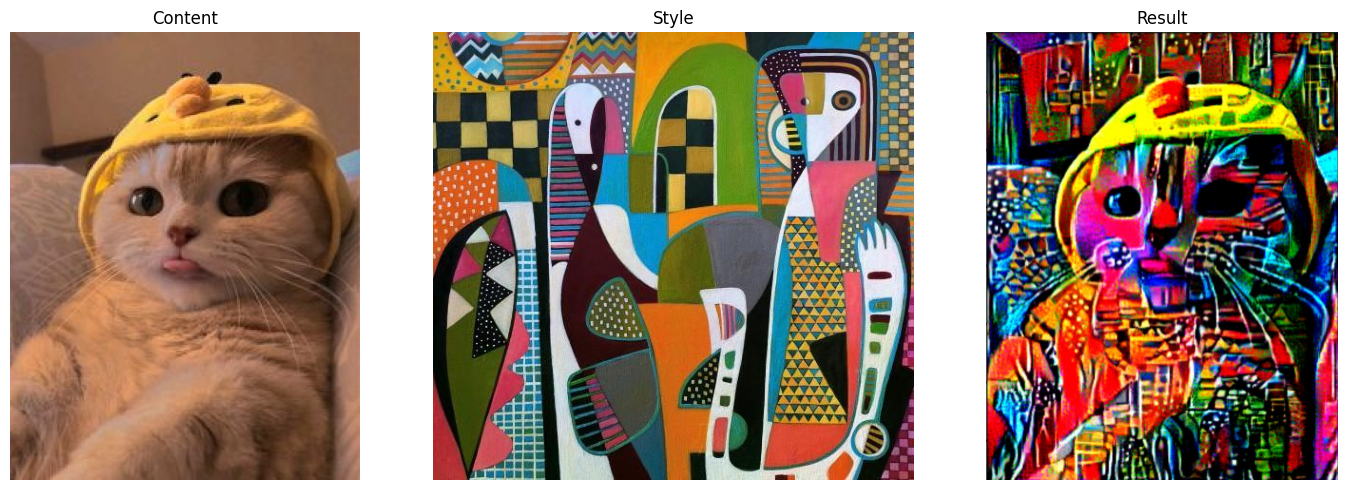

In [63]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

content_img = mpimg.imread("/content/Project-NST/content1jpg.jpg")
style_img = mpimg.imread("/content/Project-NST/style1jpg.jpg")
output_img = mpimg.imread("/content/Project-NST/new1.jpg")

def display_images(content_img, style_img, output_img):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(content_img)
    axes[0].set_title("Content")
    axes[0].axis('off')

    axes[1].imshow(style_img)
    axes[1].set_title("Style")
    axes[1].axis('off')

    axes[2].imshow(output_img)
    axes[2].set_title("Result")
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

display_images(content_img, style_img, output_img)

In [13]:
!pip install torch torchvision

In [14]:
!git clone https://github.com/parth1620/Project-NST.git

fatal: destination path 'Project-NST' already exists and is not an empty directory.


In [15]:
#Для решения задачи воспользуемся параметрами из предобученной VGG19.
import torch
from torchvision import models

vgg = models.vgg19(pretrained=True)
print(vgg)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padd

In [16]:
vgg = vgg.features
print(vgg)

Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU(inplace=True)
  (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (17): ReLU(inplace=True)
  (18): MaxPoo

In [17]:
for parameters in vgg.parameters():
  parameters.requires_grad_(False)

In [18]:
dev = torch.device("cuda" if torch.cuda.is_available else "cpu")
print(dev)

cuda


In [19]:
dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(dev)

vgg.to(dev)

cpu


Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU(inplace=True)
  (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (17): ReLU(inplace=True)
  (18): MaxPoo

In [20]:
#Предобработка изображений
from PIL import Image
from torchvision import transforms as T

def preprocess(img_path, max_size=500):
    image = Image.open(img_path).convert("RGB")
    size = max_size if max(image.size) > max_size else max(image.size)
    img_transforms = T.Compose([
        T.Resize(size),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406],
                    std=[0.229, 0.224, 0.225])
    ])
    image = img_transforms(image)
    image = image.unsqueeze(0)
    return image


In [58]:
content_preprocess = preprocess("/content/Project-NST/content1jpg.jpg")
style_preprocess = preprocess("/content/Project-NST/style1jpg.jpg")



content_preprocess = content_preprocess.to(dev)
style_preprocess = style_preprocess.to(dev)

print(f"Content shape: {content_preprocess.shape}")
print(f"Style shape: {style_preprocess.shape}")

Content shape: torch.Size([1, 3, 386, 302])
Style shape: torch.Size([1, 3, 500, 537])


In [26]:
#Преобразование вектора в картинку
import numpy as np
import matplotlib.pyplot as plt

def deprocess(tensor):
  image = tensor.to("cpu").clone()
  image = image.numpy()
  image = image.squeeze(0)
  image = image.transpose(1, 2, 0)
  image = image * np.array([0.485, 0.456, 0.406]) + np.array([0.229, 0.224, 0.225])
  image = image.clip(0,1)

  return image
content_deproc = deprocess(content_preprocess)
style_deproc = deprocess(style_preprocess)

print(f"Deprocess content: {content_deproc.shape}")
print(f"Deprocess style: {style_deproc.shape}")

Deprocess content: (386, 302, 3)
Deprocess style: (500, 537, 3)


In [27]:
content_deproc = deprocess(content_preprocess)
style_deproc = deprocess(style_preprocess)

print(f"Deprocess content: {content_deproc.shape}")
print(f"Deprocess style: {style_deproc.shape}")

Deprocess content: (386, 302, 3)
Deprocess style: (500, 537, 3)


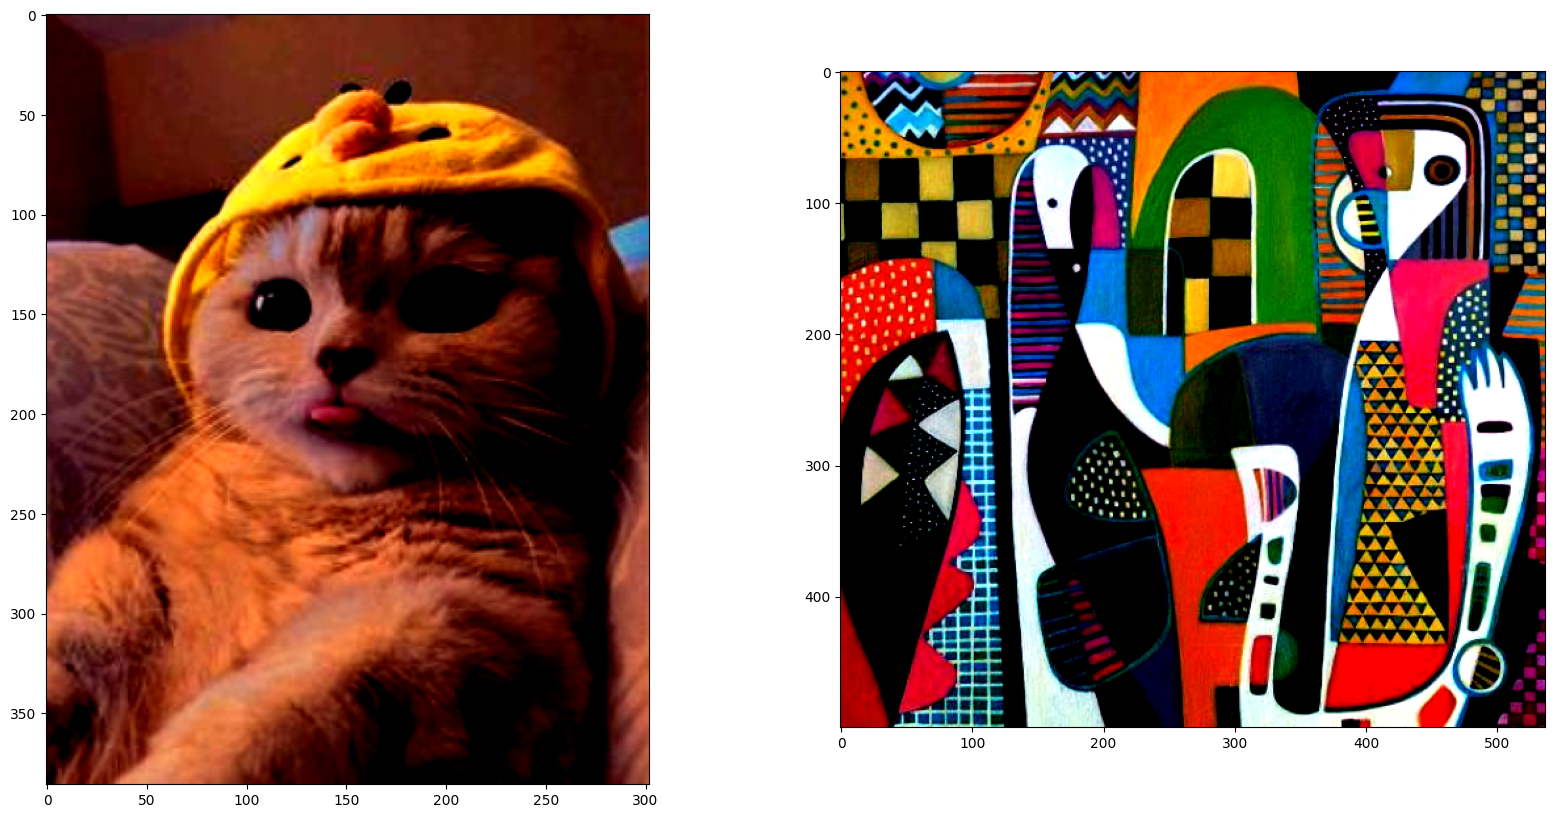

In [29]:
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(20,10))
ax1.imshow(content_deproc)
ax2.imshow(style_deproc);

In [30]:
#Извлечение признаков из картинки и стиля, построение матрицы Грама
def get_features(image, model):
  layers = {
      "0": "conv1_1",  # see representaion.png
      "5": "conv2_1",
      "10": "conv3_1",
      "19": "conv4_1",
      "21": "conv4_2", #content_feature
      "28": "conv5_1"
  }

  x = image
  Features = {}
  for name, layer in model._modules.items():
    x = layer(x)
    if name in layers:
      Features[layers[name]] = x

  return Features

In [31]:
content_features = get_features(content_preprocess, vgg)
style_features = get_features(style_preprocess, vgg)

In [32]:
def gram_matrix(tensor):
  b, c, h, w = tensor.size()
  tensor = tensor.view(c, h*w)
  gram = torch.mm(tensor, tensor.t())
  return gram

In [33]:
style_grams = {layer: gram_matrix(style_features[layer]) for layer in style_features}

In [34]:
#Создание функций потерь для картинки и стиля
def content_loss(target_conv4_2, content_conv4_2):
  loss = torch.mean((target_conv4_2-content_conv4_2)**2)
  return loss

In [35]:
style_weights = {
    "conv1_1": 1.0,
    "conv2_1": 0.75,
    "conv3_1": 0.75,
    "conv4_1": 0.75,
    "conv5_1": 0.75
}

In [36]:
def style_loss(style_weights, target_fs, style_grams):
  loss = 0
  for layer in style_weights:
    target_feature = target_fs[layer]
    target_gram = gram_matrix(target_feature)
    style_gram = style_grams[layer]
    b, c, h, w = target_feature.shape
    layer_loss = style_weights[layer]*torch.mean((target_gram-style_gram)**2)
    loss += layer_loss/(c*h*w)

  return loss

In [37]:
target = content_preprocess.clone().requires_grad_(True).to(dev)
target_f = get_features(target,vgg)
print(f"Content loss: {content_loss(target_f['conv4_2'], content_features['conv4_2'])}")
print(f"Style loss: {style_loss(style_weights, target_f,style_grams)}")

Content loss: 0.0
Style loss: 4067.395263671875


In [38]:
#Обучение модели
from torch import optim

optimizer = optim.Adam([target],lr=0.003)

alpha = 1.0
beta = 1e5
epochs = 4000
show_every = 500

In [39]:
def total_loss(c_loss, s_loss, alpha, beta):
  loss = alpha*c_loss + beta*s_loss
  return loss

In [40]:
results = []

for i in range(epochs):
  target_f = get_features(target,vgg)
  c_loss = content_loss(target_f["conv4_2"], content_features["conv4_2"])
  s_loss = style_loss(style_weights, target_f, style_grams)
  t_loss = total_loss(c_loss,s_loss, alpha, beta)

  optimizer.zero_grad()
  t_loss.backward()
  optimizer.step()

  if i % show_every == 0:
    print(f"Total loss at Epoch {i}: {t_loss}")
    results.append(deprocess(target.detach()))

Total loss at Epoch 0: 406739520.0
Total loss at Epoch 500: 46208076.0
Total loss at Epoch 1000: 23567330.0
Total loss at Epoch 1500: 14771877.0
Total loss at Epoch 2000: 9807425.0
Total loss at Epoch 2500: 7002501.5
Total loss at Epoch 3000: 5511922.0
Total loss at Epoch 3500: 4578046.0


In [ ]:
plt.figure(figsize=(10,8))
for i,_ in enumerate(results):
  plt.subplot(4,2, i+1)
  plt.imshow(results[i])
plt.show()

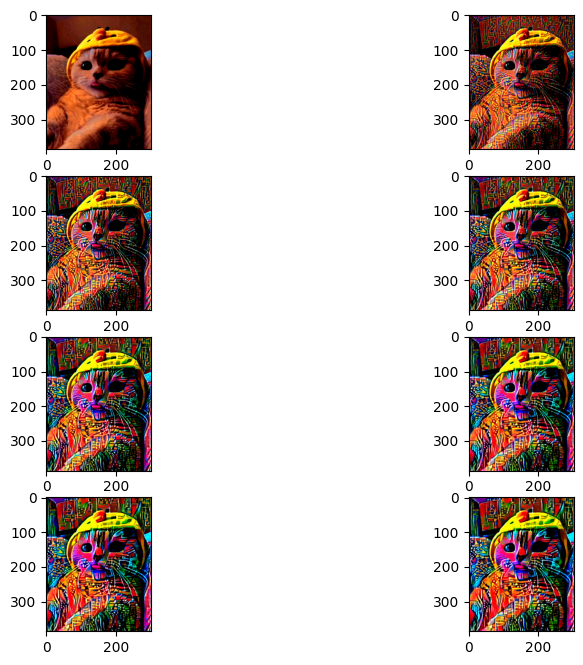

In [43]:
plt.figure(figsize=(10,8))
for i,_ in enumerate(results):
  plt.subplot(4,2, i+1)
  plt.imshow(results[i])
plt.show()

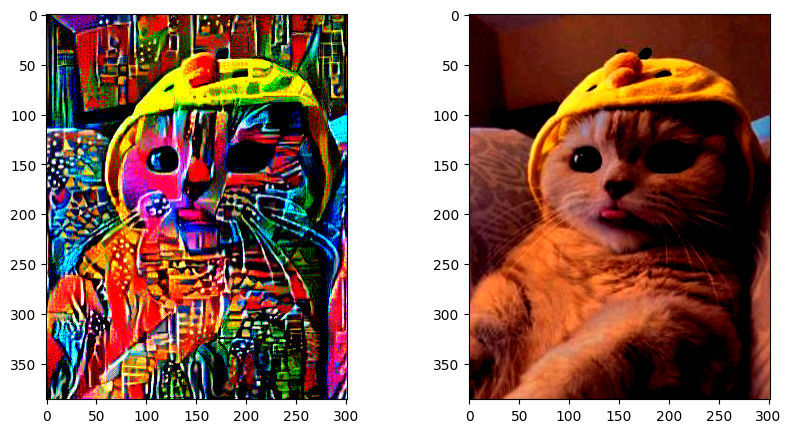

In [44]:

target_copy = deprocess(target.detach())
content_copy = deprocess(content_preprocess)

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10,5))
ax1.imshow(target_copy)
ax2.imshow(content_copy);

#Часть 2

Возьмём типовой датасет из 60 000 изображений 32 на 32. (CIFAR-10)

In [119]:
pip install torch torchvision torchaudio


In [122]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [124]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

In [125]:
dataset = datasets.CIFAR10(root='data', train=True, download=True, transform=transform)
dataloader = DataLoader(dataset, batch_size=128, shuffle=True)

Files already downloaded and verified


In [133]:
import torch.nn as nn


In [134]:
class Generator(nn.Module):
    def __init__(self, noise_dim):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(noise_dim, 256),
            nn.ReLU(True),
            nn.Linear(256, 512),
            nn.ReLU(True),
            nn.Linear(512, 1024),
            nn.ReLU(True),
            nn.Linear(1024, 3 * 32 * 32),
            nn.Tanh()
        )

    def forward(self, x):
        return self.model(x).view(-1, 3, 32, 32)

In [135]:

class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(3 * 32 * 32, 1024),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = x.view(-1, 3 * 32 * 32)
        return self.model(x)

In [139]:
device = "cuda" if torch.cuda.is_available() else "cpu"

# Создание моделей
generator = Generator(noise_dim=100).to(device)
discriminator = Discriminator().to(device)

criterion = nn.BCELoss()

lr = 0.0002
optimizer_G = torch.optim.Adam(generator.parameters(), lr=lr, betas=(0.5, 0.999))
optimizer_D = torch.optim.Adam(discriminator.parameters(), lr=lr, betas=(0.5, 0.999))

In [137]:
#Обучаем модель
import numpy as np

num_epochs = 50
noise_dim = 100

for epoch in range(num_epochs):
    for i, (real_images, _) in enumerate(dataloader):
        batch_size = real_images.size(0)
        real_images = real_images.to(device)

        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)

        # Обучаем дискриминатор
        optimizer_D.zero_grad()
        outputs = discriminator(real_images)
        real_loss = criterion(outputs, real_labels)

        noise = torch.randn(batch_size, noise_dim).to(device)
        fake_images = generator(noise)
        outputs = discriminator(fake_images.detach())
        fake_loss = criterion(outputs, fake_labels)

        d_loss = real_loss + fake_loss
        d_loss.backward()
        optimizer_D.step()

        # Обучаем генератор
        optimizer_G.zero_grad()
        outputs = discriminator(fake_images)
        g_loss = criterion(outputs, real_labels)

        g_loss.backward()
        optimizer_G.step()

    print(f"Epoch [{epoch+1}/{num_epochs}], d_loss: {d_loss.item()}, g_loss: {g_loss.item()}")

Epoch [1/50], d_loss: 0.2322818636894226, g_loss: 6.414322853088379
Epoch [2/50], d_loss: 0.06531089544296265, g_loss: 8.181806564331055
Epoch [3/50], d_loss: 0.12299633026123047, g_loss: 6.745597839355469
Epoch [4/50], d_loss: 0.38869306445121765, g_loss: 8.697089195251465
Epoch [5/50], d_loss: 0.33932340145111084, g_loss: 6.3263468742370605
Epoch [6/50], d_loss: 0.4264386296272278, g_loss: 4.294264316558838
Epoch [7/50], d_loss: 0.3539085388183594, g_loss: 4.005627155303955
Epoch [8/50], d_loss: 0.43795260787010193, g_loss: 4.590838432312012
Epoch [9/50], d_loss: 0.47843417525291443, g_loss: 2.8558812141418457
Epoch [10/50], d_loss: 0.6120430827140808, g_loss: 2.804036855697632
Epoch [11/50], d_loss: 0.6468956470489502, g_loss: 2.827446460723877
Epoch [12/50], d_loss: 0.6953184604644775, g_loss: 2.987865447998047
Epoch [13/50], d_loss: 0.7388724088668823, g_loss: 2.476449489593506
Epoch [14/50], d_loss: 0.6983000040054321, g_loss: 2.6146082878112793
Epoch [15/50], d_loss: 0.777958035

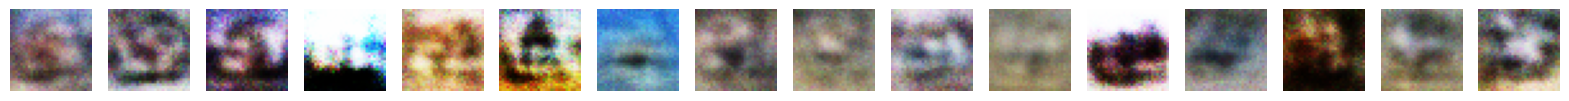

In [138]:
#Вывод результатов
import matplotlib.pyplot as plt

def save_generated_images(generator, epoch, noise_dim=100, num_images=16):
    generator.eval()
    noise = torch.randn(num_images, noise_dim).to(device)
    fake_images = generator(noise)
    fake_images = fake_images.cpu().detach()

    fig, axes = plt.subplots(1, num_images, figsize=(20, 5))
    for i, img in enumerate(fake_images):
        axes[i].imshow((img.permute(1, 2, 0) * 0.5 + 0.5).numpy())
        axes[i].axis('off')
    plt.show()
    generator.train()

save_generated_images(generator, num_epochs)